# Customer Churn Analysis – Machine Learning Project

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans 

In [3]:
df = pd.read_excel("cust_segmentation.xlsx")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


STEP 2: DATA UNDERSTANDING 

In step 2, I performed data understanding by checking dataset shape, data types, missing values, and statistical distribution to identify cleaning requirements.

In [4]:
df. shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df.isnull().sum() 

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#STEP 3: DATA CLEANING

In the data understanding phase, I identified missing CustomerID values and negative Quantity and UnitPrice values, which were removed during data cleaning to ensure model reliability.

In [8]:
# Remove missing CustomerID
df = df.dropna(subset=["CustomerID"]) 

In [9]:
df.isnull().sum() 

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
# Step : Remove negative & zero Quantity
df = df[df["Quantity"] > 0] 

In [11]:
# Step: Remove zero & negative UnitPrice
df = df[df["UnitPrice"] > 0] 

In [12]:
# Step: Reset index 
df = df.reset_index(drop=True) 

STEP 4: Feature Engineering

In [13]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"] 

In [14]:
customer_df = df.groupby("CustomerID").agg({
    "TotalAmount": "sum",
    "Quantity": "sum",
    "InvoiceNo": "nunique"
}).reset_index()


In [15]:
customer_df

,CustomerID,TotalAmount,Quantity,InvoiceNo
0,12346.0,77183.60,74215,1
1,12347.0,4310.00,2458,7
2,12348.0,1797.24,2341,4
3,12349.0,1757.55,631,1
4,12350.0,334.40,197,1
...,...,...,...,...
4333,18280.0,180.60,45,1
4334,18281.0,80.82,54,1
4335,18282.0,178.05,103,2
4336,18283.0,2094.88,1397,16


In [16]:
customer_df.rename(columns={
    "TotalAmount": "TotalSpend",
    "Quantity": "TotalQuantity",
    "InvoiceNo": "InvoiceCount"
}, inplace=True)

I engineered features by creating total transaction value and aggregating transactional data into customer-level metrics such as total spend, quantity, and order frequency.

In [17]:
customer_df 

,CustomerID,TotalSpend,TotalQuantity,InvoiceCount
0,12346.0,77183.60,74215,1
1,12347.0,4310.00,2458,7
2,12348.0,1797.24,2341,4
3,12349.0,1757.55,631,1
4,12350.0,334.40,197,1
...,...,...,...,...
4333,18280.0,180.60,45,1
4334,18281.0,80.82,54,1
4335,18282.0,178.05,103,2
4336,18283.0,2094.88,1397,16


STEP 5: Feature Scaling

In [18]:
features = customer_df[["TotalSpend", "TotalQuantity", "InvoiceCount"]] 

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [20]:
scaled_features

array([[ 8.35866818e+00,  1.44730378e+01, -4.25096503e-01],
       [ 2.50966264e-01,  2.51057567e-01,  3.54416797e-01],
       [-2.85960063e-02,  2.27868586e-01, -3.53398530e-02],
       ...,
       [-2.08742313e-01, -2.15694995e-01, -2.95177619e-01],
       [ 4.51854273e-03,  4.07711685e-02,  1.52368675e+00],
       [-2.41412739e-02,  7.82302913e-02, -1.65258736e-01]],
      shape=(4338, 3))

In [21]:
from sklearn.cluster import KMeans

# Step 6: Choosing Number of Clusters

In [22]:
inertia = []

for k in range(1, 11):   # try K = 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

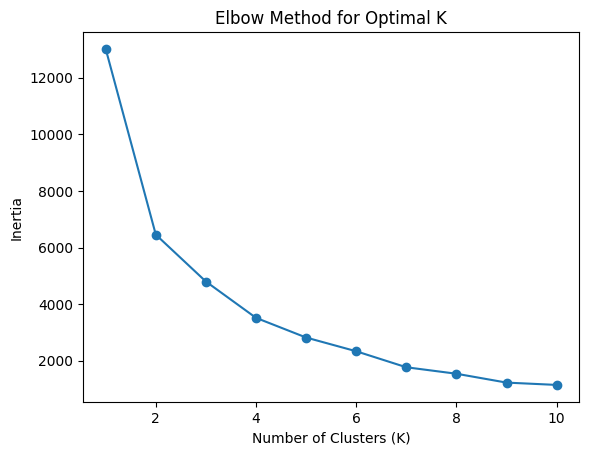

In [23]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

# Step 7: Model Building

I applied K-Means with K = 3 and assigned cluster labels to each customer.

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42) 

In [25]:
customer_df["Cluster"] = kmeans.fit_predict(scaled_features) 

In [26]:
customer_df

,CustomerID,TotalSpend,TotalQuantity,InvoiceCount,Cluster
0,12346.0,77183.60,74215,1,1
1,12347.0,4310.00,2458,7,0
2,12348.0,1797.24,2341,4,0
3,12349.0,1757.55,631,1,0
4,12350.0,334.40,197,1,0
...,...,...,...,...,...
4333,18280.0,180.60,45,1,0
4334,18281.0,80.82,54,1,0
4335,18282.0,178.05,103,2,0
4336,18283.0,2094.88,1397,16,2


# STEP 8: CLUSTER INTERPRETATION

In [27]:
customer_df.groupby("Cluster").mean() 

,CustomerID,TotalSpend,TotalQuantity,InvoiceCount
Cluster,,,,
0,15305.218422,1091.627050,649.209382,3.072319
1,15157.470588,112694.244706,64501.000000,70.352941
2,15224.710526,11085.860658,6202.109649,20.881579


In [ ]:
customer_df["Cluster"].value_counts() 


Cluster
0    4093
2     228
1      17
Name: count, dtype: int64

In [29]:
cluster_map = {
    0: "Low Value",
    1: "High Value",
    2: "Medium Value"
}

customer_df["CustomerSegment"] = customer_df["Cluster"].map(cluster_map) 

In [30]:
customer_df.head()


,CustomerID,TotalSpend,TotalQuantity,InvoiceCount,Cluster,CustomerSegment
0,12346.0,77183.60,74215,1,1,High Value
1,12347.0,4310.00,2458,7,0,Low Value
2,12348.0,1797.24,2341,4,0,Low Value
3,12349.0,1757.55,631,1,0,Low Value
4,12350.0,334.40,197,1,0,Low Value


After clustering, I analyzed cluster-wise averages to identify high-, medium-, and low-value customer segments.

In [ ]:
customer_df.to_csv("customer_segments.csv", index=False) 

In [34]:
import os
os.listdir() 

['customer_churn.ipynb',
 'customer_segments.csv',
 'cust_segmentation.xlsx',
 'requirements.txt',
 'venv']

Step 8: Visualization & Insights

I visualized customer segments using scatter plots and derived business recommendations based on each segment.

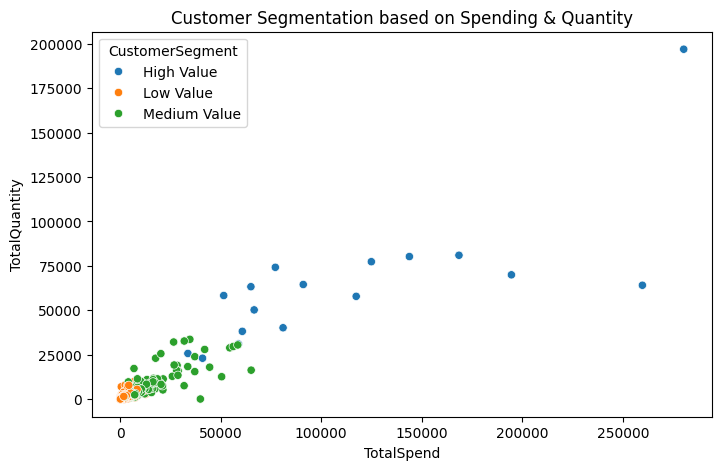

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="TotalSpend", 
    y="TotalQuantity",
    hue="CustomerSegment",
    data=customer_df
)
plt.title("Customer Segmentation based on Spending & Quantity")
plt.show()


# Conclusion

In [33]:
customer_df["CustomerSegment"].value_counts() 

CustomerSegment
Low Value       4093
Medium Value     228
High Value        17
Name: count, dtype: int64

I segmented customers using K-Means and labeled them into high- and low-value groups based on spending and purchase behavior, then visualized the segments and derived business insights.

The model successfully segmented customers into meaningful groups that can be used for targeted marketing, customer retention, and business growth.